# Patient Statement Redesign: A/B Test Simulation
**Author:** Mokshith Talari  
**Data:** 100% synthetic, generated by `generate_dataset.py`. Treatment effects are simulation parameters; this notebook demonstrates method, not a real-world result.

## 1. Design
- **Hypothesis:** a plain-language statement with a QR payment link and payment-plan option reduces days to pay.
- **Unit of randomization:** patient (all of a patient's statements get the same template).
- **Primary metric:** days from statement to settlement (paid statements).
- **Secondary:** paid within 30 days; unpaid at 120 days; QR/mobile share.
- **Guardrail:** dispute rate must not increase.
- **Power:** to detect a 1.2-day difference with SD about 14.5, alpha 0.05 (two-sided), power 0.80, about 2,300 statements per arm are needed; this design is well powered.

In [1]:
import json, pandas as pd
from run_analysis import analyze, report
df = pd.read_csv('data/patient_billing_cohorts.csv')
df.head()

,statement_id,patient_id,cohort_group,statement_date,payment_date,days_to_pay,patient_balance,balance_tier,primary_payor,patient_age_group,paid_within_30_days,payment_channel,dispute_flag
0,STMT-100000,PAT-13123,Control,2024-02-06,2024-03-11,34.0,70.01,Low (<$150),BlueCross BlueShield,36-55,0,Mail_Check,0
1,STMT-100001,PAT-37088,Control,2024-02-19,2024-03-22,32.0,186.61,Medium ($150-$500),BlueCross BlueShield,18-35,0,QR_Portal,0
2,STMT-100002,PAT-32910,Treatment,2024-01-12,2024-02-08,27.0,215.40,Medium ($150-$500),Aetna,18-35,1,QR_Portal,0
3,STMT-100003,PAT-25360,Control,2024-01-24,2024-04-15,82.0,317.17,Medium ($150-$500),UnitedHealthcare,56+,0,Mail_Check,0
4,STMT-100004,PAT-25155,Control,2024-02-06,2024-04-21,75.0,71.72,Low (<$150),Cigna,36-55,0,QR_Portal,0


## 2. Validity checks, primary and secondary results

In [2]:
r = analyze(df)
report(r)

Patients: {'Control': 13227, 'Treatment': 13423} | Statements: {'Control': 24633, 'Treatment': 25367} | SRM p=0.230
Balance check p=0.692 | Age balance p=0.828
Days to pay: C 49.49 vs T 42.36 | diff 7.13 [95% CI 6.87, 7.39] | Welch p=0.00e+00
  Patient-level (cluster-robust) diff 7.05, p=0.00e+00
resolution_30d: C 8.65% vs T 17.83% (+9.18 pp, p=1.06e-200)
unpaid: C 11.61% vs T 8.09% (-3.52 pp, p=6.10e-40)
dispute: C 3.30% vs T 2.76% (-0.54 pp, p=4.59e-04)
Business case (illustrative): one-time cash $509,183; annual carrying-cost $40,735; annual balances no longer unpaid $917,775


## 3. Subgroups (days faster, control minus treatment)

In [3]:
pd.DataFrame({'by age': r['age_days_delta']}).join(pd.Series(r['tier_days_delta'], name='by balance tier'), how='outer')

,by age,by balance tier
18-35,7.81,NaN
36-55,7.22,NaN
56+,6.32,NaN
High (>$500),NaN,6.89
Low (<$150),NaN,6.81
Medium ($150-$500),NaN,7.48


## 4. Figures

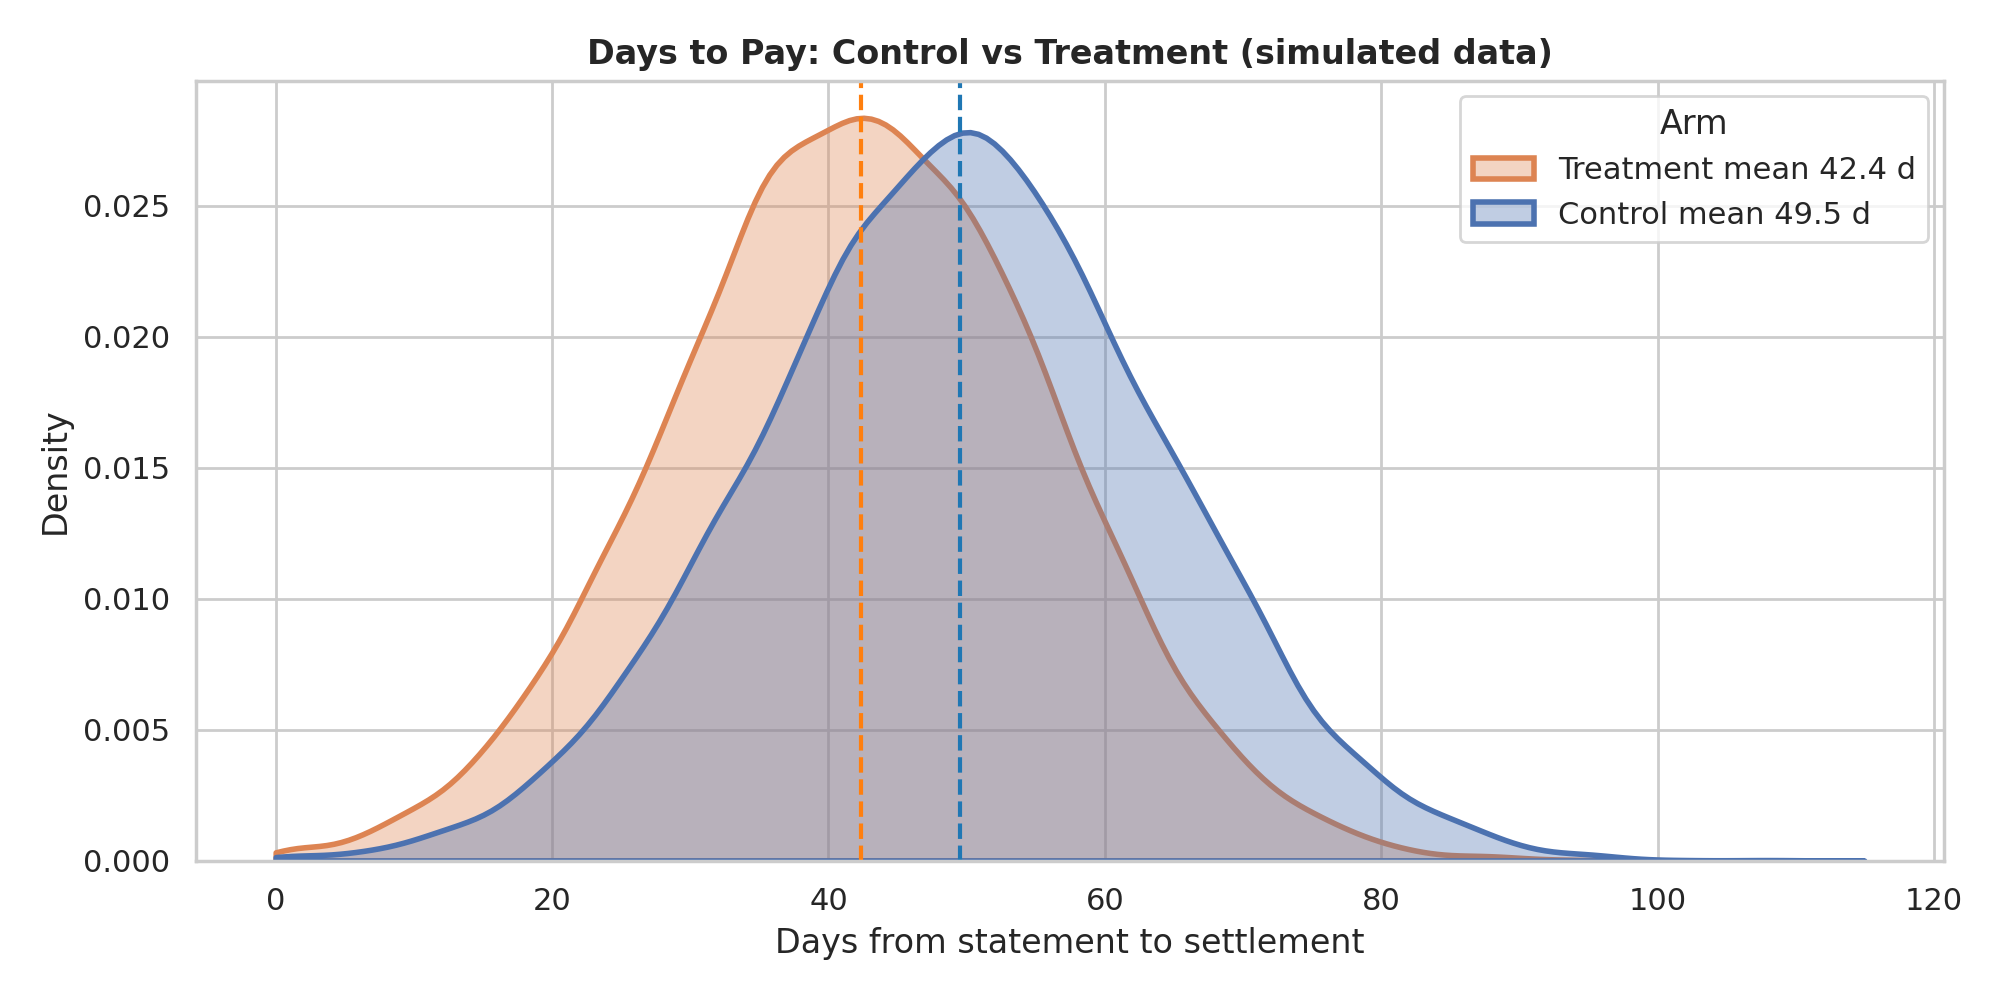

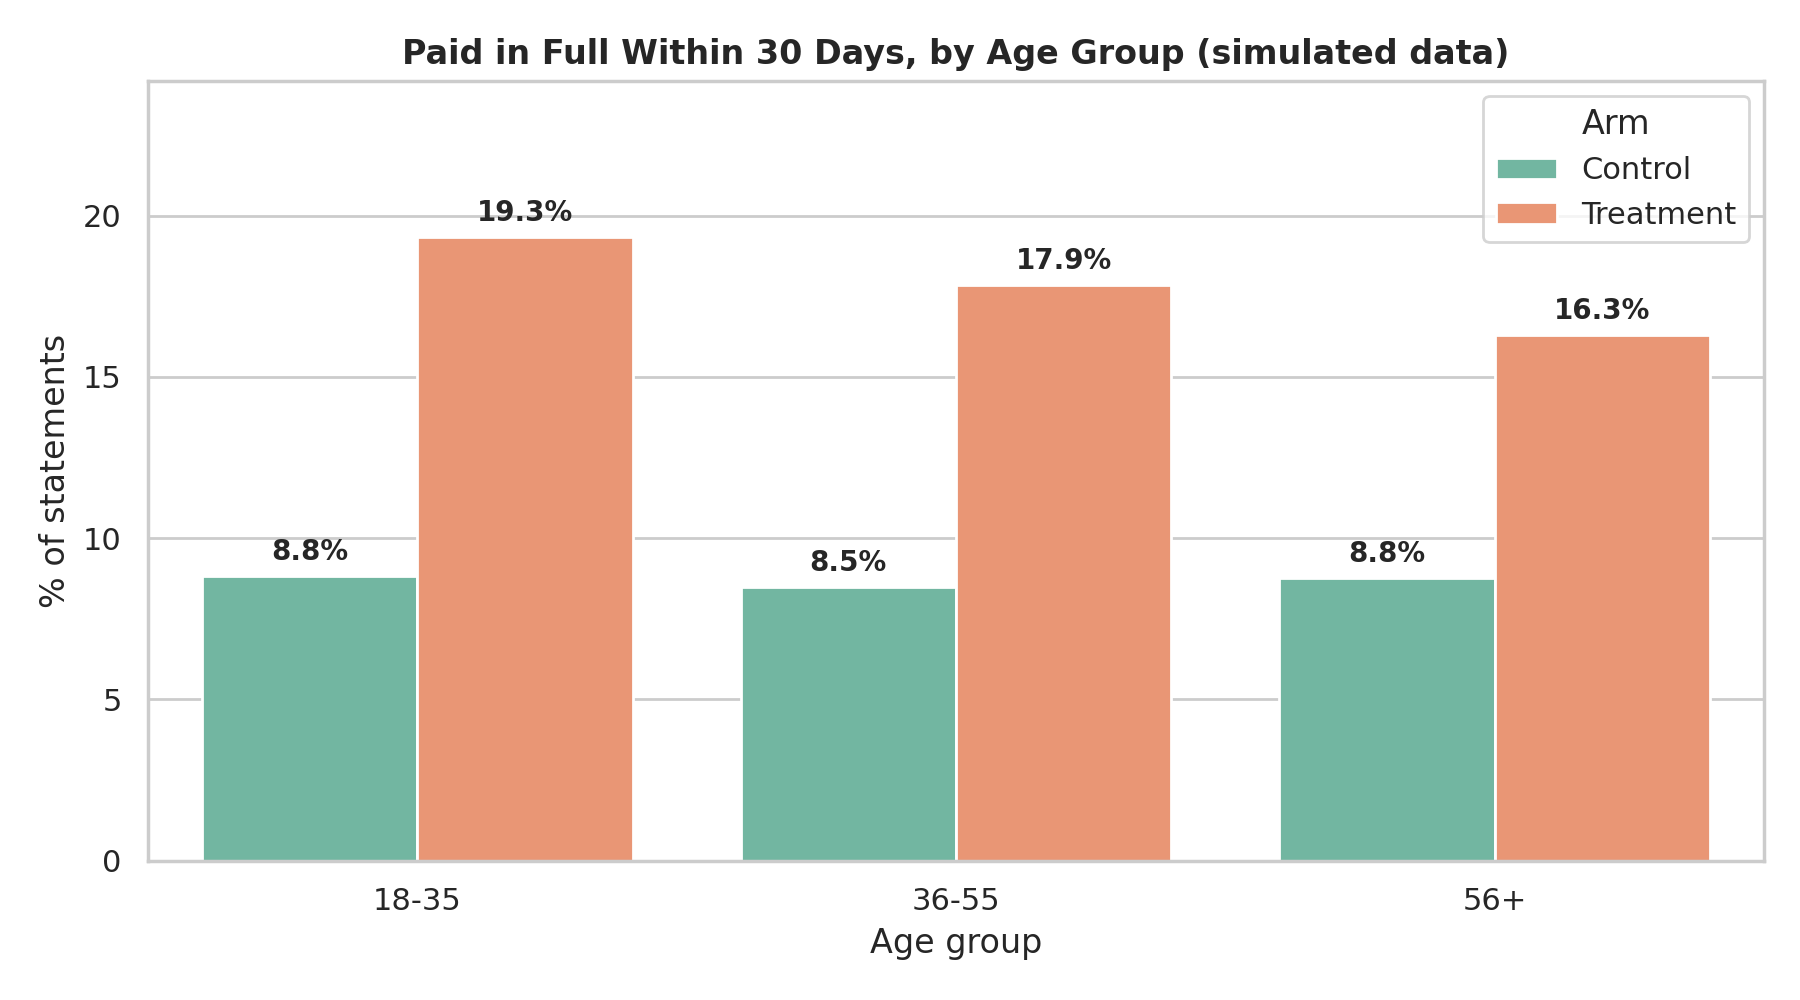

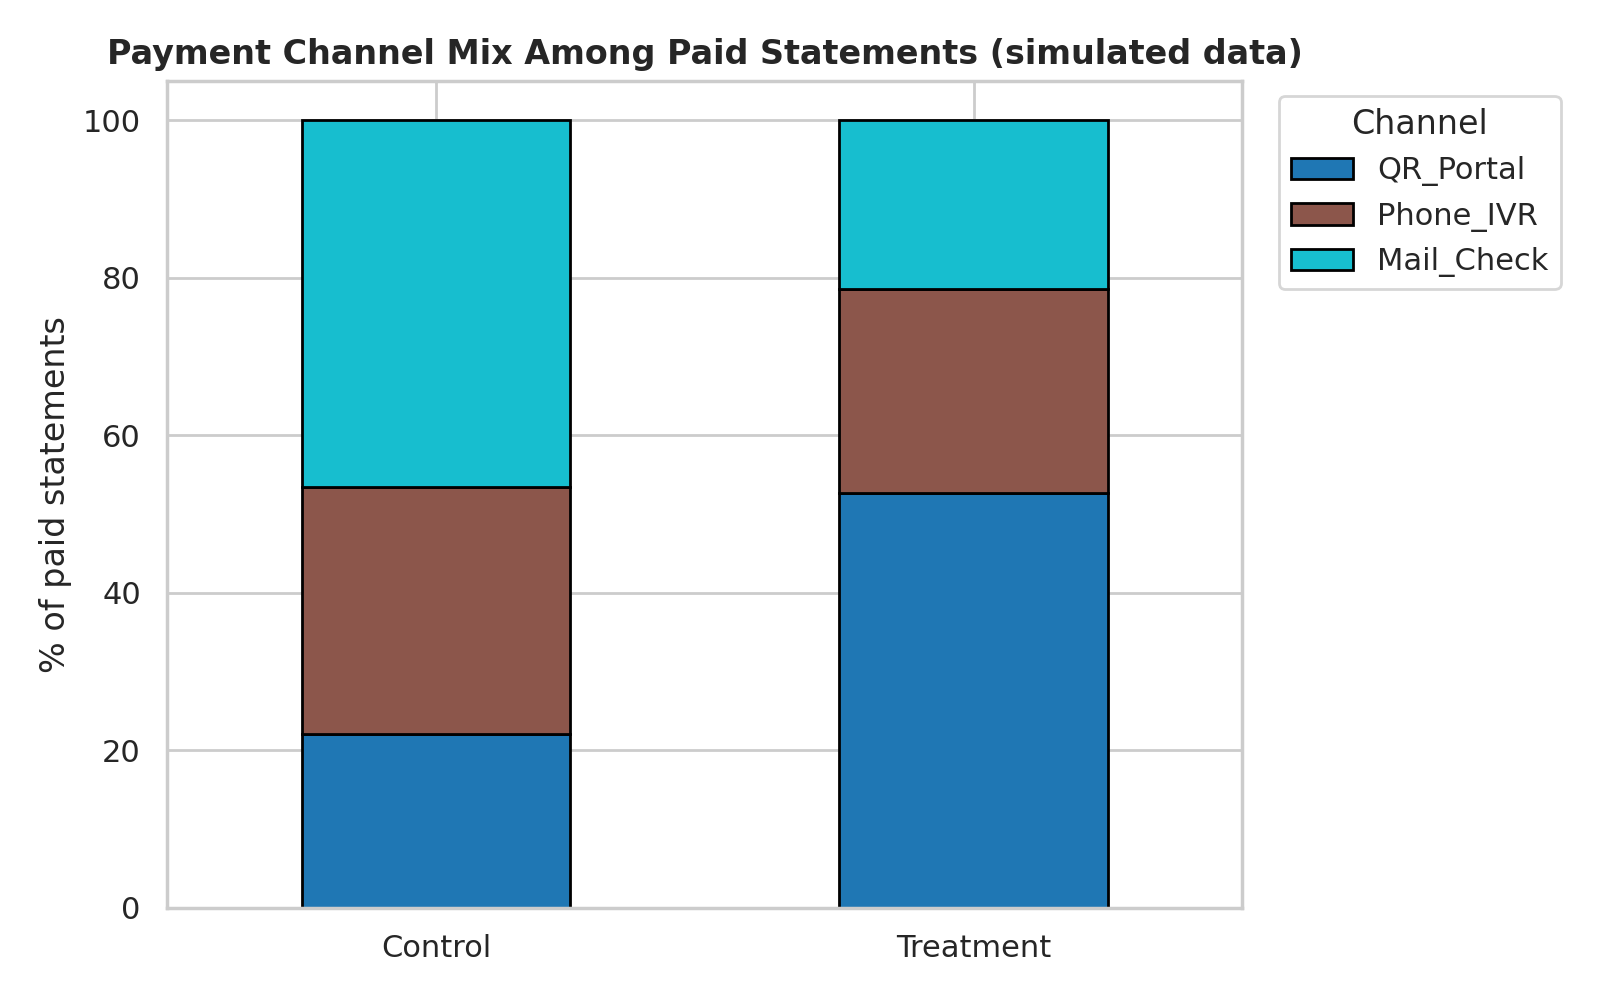

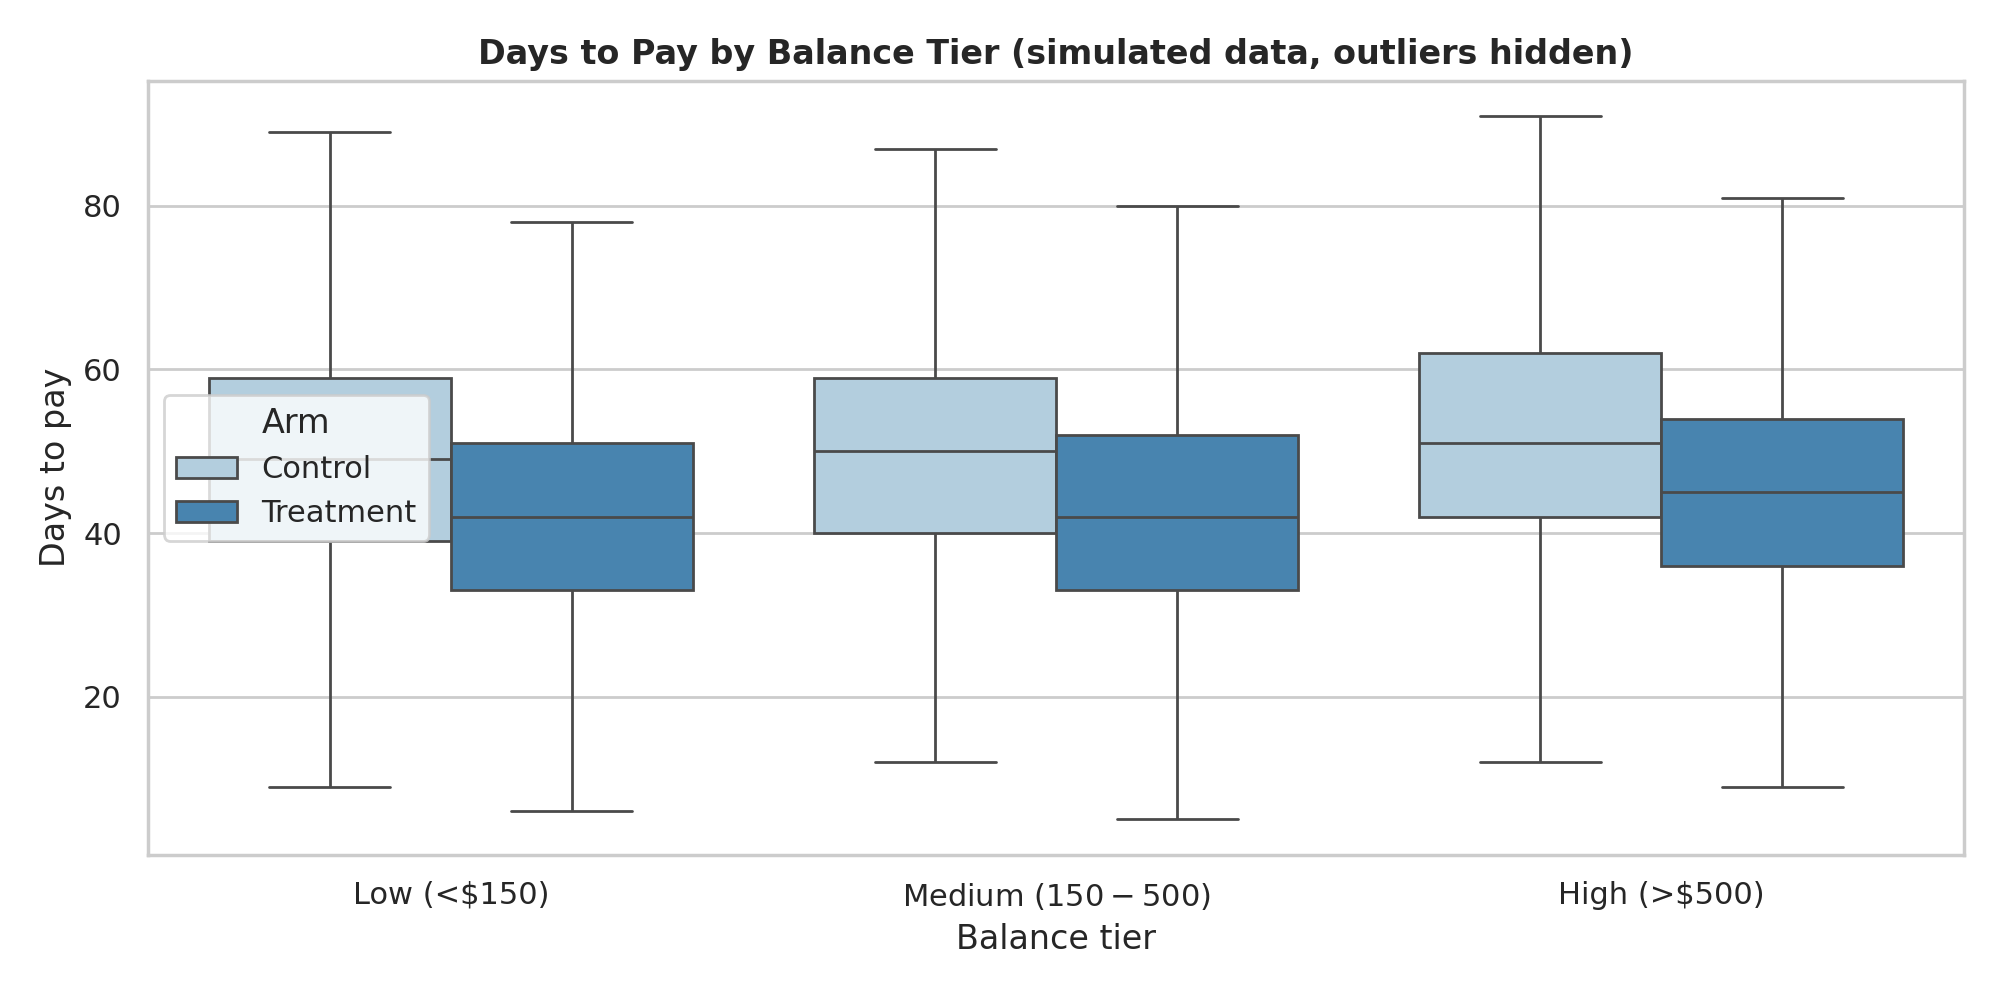

In [4]:
from IPython.display import Image, display
for f in ['figure1_distribution_days_to_pay', 'figure2_resolution_rates_by_age',
          'figure3_channel_shift', 'figure4_balance_tier_boxplot']:
    display(Image(f'figures/{f}.png', width=750))

## 5. Illustrative business case
Assumptions live in `ASSUMPTIONS` in `run_analysis.py`. One-time cash acceleration and annual effects are reported separately and should not be summed.

In [5]:
pd.Series(r['business_case'])

annual_statement_volume                                                        120000
cost_of_capital                                                                  0.08
note                                Illustrative scenario only; not derived from a...
annual_self_pay_base                                                     26065187.976
one_time_cash_acceleration                                              509183.122094
annual_carrying_cost_saving                                              40734.649768
annual_balances_no_longer_unpaid                                        917774.556847
dtype: object

## 6. Recommendation and limitations
- Roll out, keeping a 5-10% holdout for one billing cycle to confirm the effect in production.
- The statement bundles three changes (layout, QR, payment plan); a follow-up factorial test would isolate each.
- Real data would add seasonality, payer adjudication lag, and right-censoring; a survival model (Kaplan-Meier / Cox) would handle unpaid balances better than dropping them from the days-to-pay mean.